### Нулевой ноутбук: Разведывательный анализ исходных данных

**Цель:** Исследовать структуру, качество и особенности исходных данных до начала очистки.

In [15]:

import os
import sys
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка рабочей директории на корень проекта
def setup_project_root():
    current = os.getcwd()
    root = current
    while True:
        if os.path.exists(os.path.join(root, 'data')):
            break
        new_root = os.path.dirname(root)
        if new_root == root:
            root = current
            break
        root = new_root
    os.chdir(root)
    print(f"Корень проекта: {root}")
    return root

PROJECT_ROOT = setup_project_root()

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Загрузка исходных данных
df = pd.read_csv('data/data.csv')

print("=== ОБЩАЯ ИНФОРМАЦИЯ ===")
print(f"Размер: {df.shape[0]:,} строк, {df.shape[1]} колонок")
print(f"\nКолонки: {df.columns.tolist()}")


Корень проекта: c:\Users\washe\Documents\SF_Training_DS\Диплом
=== ОБЩАЯ ИНФОРМАЦИЯ ===
Размер: 377,185 строк, 18 колонок

Колонки: ['status', 'private pool', 'propertyType', 'street', 'baths', 'homeFacts', 'fireplace', 'city', 'schools', 'sqft', 'zipcode', 'beds', 'state', 'stories', 'mls-id', 'PrivatePool', 'MlsId', 'target']


### 2. Анализ типов данных и пропусков

**Цель:** Выявить колонки с неправильными типами данных и оценить объём пропусков.

In [16]:
print("=== ТИПЫ ДАННЫХ ===")
print(df.dtypes)

print("\n=== ПРОПУСКИ ===")
missing = df.isnull().sum()
missing_pct = 100 * missing / len(df)
missing_df = pd.DataFrame({'пропусков': missing, '%': missing_pct})
missing_df[missing_df['пропусков'] > 0].sort_values('%', ascending=False)


=== ТИПЫ ДАННЫХ ===
status          object
private pool    object
propertyType    object
street          object
baths           object
homeFacts       object
fireplace       object
city            object
schools         object
sqft            object
zipcode         object
beds            object
state           object
stories         object
mls-id          object
PrivatePool     object
MlsId           object
target          object
dtype: object

=== ПРОПУСКИ ===


,пропусков,%
private pool,373004,98.891525
mls-id,352243,93.387330
PrivatePool,336874,89.312672
fireplace,274071,72.662221
stories,150716,39.958111
baths,106338,28.192532
beds,91282,24.200856
MlsId,66880,17.731352
sqft,40577,10.757851
status,39918,10.583136


### 4. Анализ числовых признаков

**Цель:** Исследовать распределение и выбросы в признаках, которые должны быть числовыми.

In [17]:
print("=== АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ ===\n")

# Признаки, которые должны быть числовыми
numeric_candidates = ['baths', 'beds', 'stories', 'sqft']

for col in numeric_candidates:
    if col in df.columns:
        # Пробуем преобразовать
        converted = pd.to_numeric(df[col], errors='coerce')
        valid_count = converted.notna().sum()
        invalid_count = df[col].isna().sum() + (converted.isna().sum() - df[col].isna().sum())

        print(f"{col}:")
        print(f"  Всего записей: {len(df):,}")
        print(f"  Валидных чисел: {valid_count:,} ({valid_count/len(df)*100:.2f}%)")
        print(f"  Пропусков в исходных: {df[col].isna().sum():,}")
        print(f"  Ошибок преобразования: {invalid_count:,}")

        # Примеры некорректных значений
        invalid_examples = df[df[col].notna() & converted.isna()][col].head(5).tolist()
        if invalid_examples:
            print(f"  Примеры некорректных значений: {invalid_examples}")
        print()

=== АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ ===

baths:
  Всего записей: 377,185
  Валидных чисел: 103,284 (27.38%)
  Пропусков в исходных: 106,338
  Ошибок преобразования: 273,901
  Примеры некорректных значений: ['3 Baths', '2 Baths', '8 Baths', '2 Baths', '3 Baths']

beds:
  Всего записей: 377,185
  Валидных чисел: 101,020 (26.78%)
  Пропусков в исходных: 91,282
  Ошибок преобразования: 276,165
  Примеры некорректных значений: ['3 Beds', '3 Beds', '5 Beds', '2 Beds', '3 Beds']

stories:
  Всего записей: 377,185
  Валидных чисел: 207,945 (55.13%)
  Пропусков в исходных: 150,716
  Ошибок преобразования: 169,240
  Примеры некорректных значений: ['One', 'Multi/Split', 'One Level', 'One', 'One']

sqft:
  Всего записей: 377,185
  Валидных чисел: 61,637 (16.34%)
  Пропусков в исходных: 40,577
  Ошибок преобразования: 315,548
  Примеры некорректных значений: ['1,947 sqft', '3,000 sqft', '6,457 sqft', '897 sqft', '1,507']



### 5. Анализ целевой переменной (target)

**Цель:** Исследовать распределение цен, выявить аномалии и понять масштаб.

=== АНАЛИЗ TARGET ===

Всего записей: 377,185
Валидных чисел: 13 (0.00%)
Пропусков в исходных: 2,481
Ошибок преобразования: 374,691

Примеры некорректных значений: ['$418,000', '$310,000', '$2,895,000', '$2,395,000', '$5,000', '$209,000', '181,500', '68,000', '$244,900', '$311,995']

Статистика по валидным ценам:
  min: $1
  max: $825
  mean: $253
  median: $25


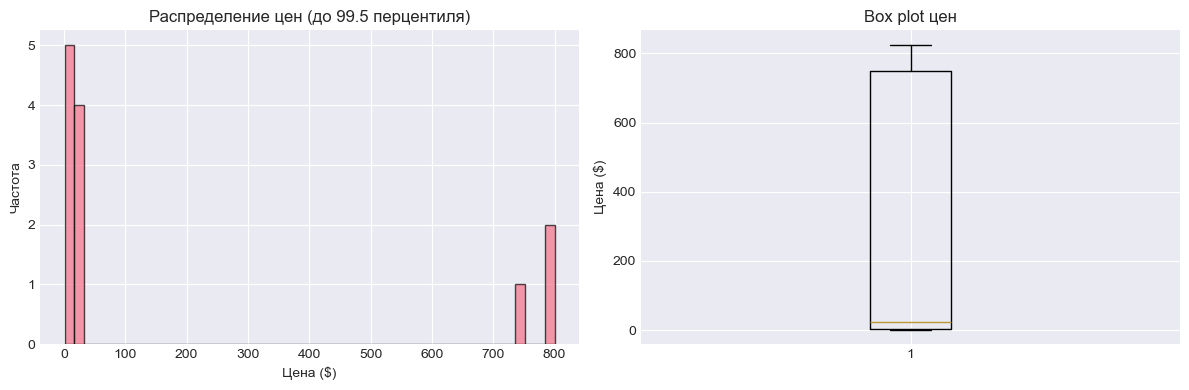

In [18]:
print("=== АНАЛИЗ TARGET ===\n")

# Пробуем преобразовать target в числа
target_converted = pd.to_numeric(df['target'], errors='coerce')
valid_target = target_converted.notna().sum()
invalid_target = target_converted.isna().sum() - df['target'].isna().sum()

print(f"Всего записей: {len(df):,}")
print(f"Валидных чисел: {valid_target:,} ({valid_target/len(df)*100:.2f}%)")
print(f"Пропусков в исходных: {df['target'].isna().sum():,}")
print(f"Ошибок преобразования: {invalid_target:,}")

# Примеры некорректных значений
invalid_examples = df[df['target'].notna() & target_converted.isna()]['target'].head(10).tolist()
print(f"\nПримеры некорректных значений: {invalid_examples}")

# Статистика по валидным значениям
valid_data = target_converted.dropna()
print(f"\nСтатистика по валидным ценам:")
print(f"  min: ${valid_data.min():,.0f}")
print(f"  max: ${valid_data.max():,.0f}")
print(f"  mean: ${valid_data.mean():,.0f}")
print(f"  median: ${valid_data.median():,.0f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма (ограничим 99.5 перцентилем)
upper = valid_data.quantile(0.995)
filtered = valid_data[valid_data <= upper]
axes[0].hist(filtered, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение цен (до 99.5 перцентиля)')
axes[0].set_xlabel('Цена ($)')
axes[0].set_ylabel('Частота')

# Box plot
axes[1].boxplot(valid_data, vert=True)
axes[1].set_title('Box plot цен')
axes[1].set_ylabel('Цена ($)')

plt.tight_layout()
plt.savefig('data_processed/eda_target_initial.png', dpi=150)
plt.show()

In [19]:
print("=== ДЕТАЛЬНЫЙ АНАЛИЗ TARGET ===\n")

# Смотрим уникальные значения target (первые 50)
unique_targets = df['target'].value_counts().head(50)
print("Топ-50 уникальных значений target:")
for val, count in unique_targets.items():
    print(f"  {val}: {count}")

print("\n" + "="*50)
print("ВЫВОДЫ ПО TARGET:")
print("1. Почти все значения содержат символы $ и ,")
print("2. Нужно очищать target от символов перед преобразованием")
print("3. После очистки можно будет получить нормальное распределение цен")

=== ДЕТАЛЬНЫЙ АНАЛИЗ TARGET ===

Топ-50 уникальных значений target:
  $225,000: 1462
  $275,000: 1355
  $250,000: 1312
  $350,000: 1296
  $299,900: 1276
  $325,000: 1244
  $249,900: 1241
  $399,000: 1239
  $199,900: 1199
  $299,000: 1176
  $375,000: 1163
  $450,000: 1141
  $499,000: 1099
  $175,000: 1096
  $425,000: 1075
  $599,000: 1012
  $265,000: 992
  $235,000: 975
  $150,000: 973
  $399,900: 963
  $285,000: 952
  $699,000: 951
  $1,000: 947
  $215,000: 947
  $185,000: 937
  $165,000: 936
  $799,000: 911
  $349,900: 906
  $149,900: 900
  $300,000: 892
  $239,900: 890
  $125,000: 888
  $650,000: 886
  $475,000: 872
  $550,000: 871
  $199,000: 855
  $179,900: 855
  $295,000: 853
  $189,900: 853
  $169,900: 850
  $315,000: 849
  $525,000: 842
  $269,900: 837
  $245,000: 828
  $195,000: 812
  $575,000: 810
  $259,900: 809
  $220,000: 808
  $159,900: 803
  $200,000: 800

ВЫВОДЫ ПО TARGET:
1. Почти все значения содержат символы $ и ,
2. Нужно очищать target от символов перед преобразован

### 7. Обоснование стратифицированного подхода

**Цель:** Доказать, что данные неоднородны и требуют разделения на сегменты.

**Анализируем:**
1. Распределение цен по типам недвижимости
2. Распределение цен по сегментам (земля, эконом, стандарт, элита)
3. Качество единой модели против сегментированных

=== АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЦЕН ПО СЕГМЕНТАМ ===

СТАТИСТИКА ПО СЕГМЕНТАМ:
                   target_clean                                              
                          count        min          max       mean     median
price_segment                                                                
Земельные участки         31535        1.0  110000000.0   316177.0    72500.0
Стандарт (500K-2M)        89675   500021.0    2000000.0   907488.0   775000.0
Эконом (<500K)           236943        1.0     500000.0   257252.0   252000.0
Элита (>2M)               16550  2003400.0  195000000.0  5394397.0  3375000.0

РАСПРЕДЕЛЕНИЕ КОЛИЧЕСТВА ОБЪЕКТОВ:
price_segment
Эконом (<500K)        236943
Стандарт (500K-2M)     89675
Земельные участки      31535
Элита (>2M)            16550
Name: count, dtype: int64


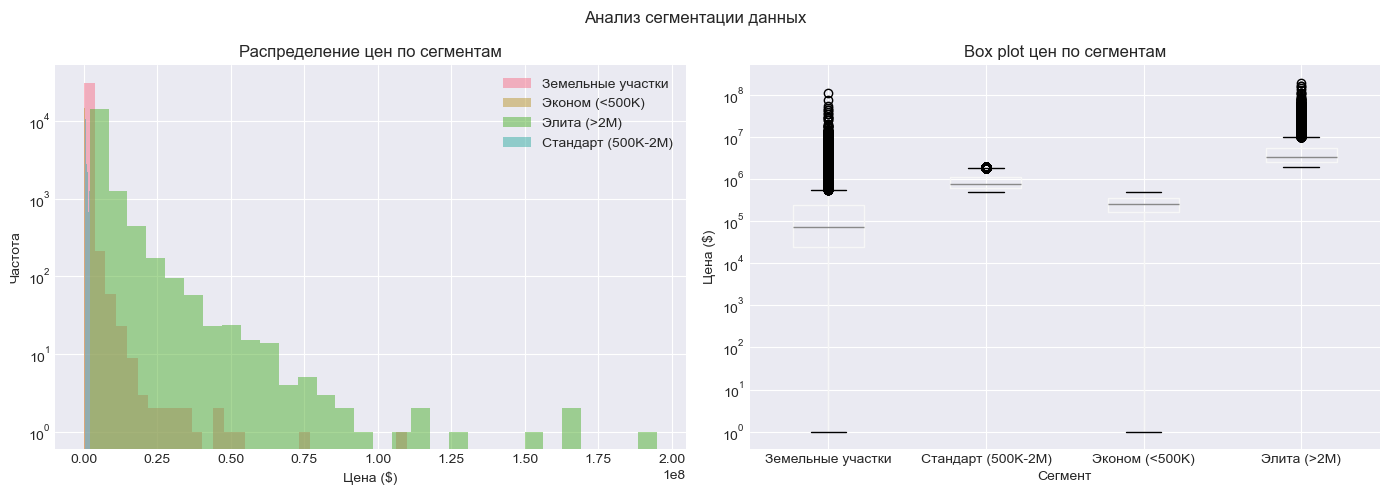

In [20]:
print("=== АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЦЕН ПО СЕГМЕНТАМ ===\n")

df_analysis = df.copy()

# Определяем земельные участки по propertyType
df_analysis['is_land'] = df_analysis['propertyType'].str.contains('lot|land', case=False, na=False).astype(int)

# Очищаем target от символов для анализа
def clean_price(price_str):
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str)
    cleaned = re.sub(r'[^\d.-]', '', price_str)
    if cleaned == '' or cleaned == '-':
        return np.nan
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

df_analysis['target_clean'] = df_analysis['target'].apply(clean_price)
df_analysis = df_analysis.dropna(subset=['target_clean'])

# Для зданий определяем ценовые сегменты
building_mask = df_analysis['is_land'] == 0
df_buildings = df_analysis[building_mask].copy()
price_bins = [0, 500000, 2000000, 1e9]
price_labels = ['Эконом (<500K)', 'Стандарт (500K-2M)', 'Элита (>2M)']
df_buildings['price_segment'] = pd.cut(df_buildings['target_clean'], bins=price_bins, labels=price_labels)

# Для земли
df_land = df_analysis[df_analysis['is_land'] == 1].copy()
df_land['price_segment'] = 'Земельные участки'

# Объединяем
df_all = pd.concat([df_land, df_buildings])

# Статистика по сегментам
print("СТАТИСТИКА ПО СЕГМЕНТАМ:")
print("="*50)
segment_stats = df_all.groupby('price_segment').agg({
    'target_clean': ['count', 'min', 'max', 'mean', 'median']
}).round(0)
print(segment_stats)

print("\nРАСПРЕДЕЛЕНИЕ КОЛИЧЕСТВА ОБЪЕКТОВ:")
print(df_all['price_segment'].value_counts())

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма цен по сегментам
for segment in df_all['price_segment'].unique():
    data = df_all[df_all['price_segment'] == segment]['target_clean']
    axes[0].hist(data, bins=30, alpha=0.5, label=segment)
axes[0].set_title('Распределение цен по сегментам')
axes[0].set_xlabel('Цена ($)')
axes[0].set_ylabel('Частота')
axes[0].legend()
axes[0].set_yscale('log')

# Box plot по сегментам
df_all.boxplot(column='target_clean', by='price_segment', ax=axes[1])
axes[1].set_title('Box plot цен по сегментам')
axes[1].set_xlabel('Сегмент')
axes[1].set_ylabel('Цена ($)')
axes[1].set_yscale('log')

plt.suptitle('Анализ сегментации данных')
plt.tight_layout()
plt.savefig('data_processed/eda_segmentation.png', dpi=150)
plt.show()

In [21]:
print("=== СРАВНЕНИЕ ПОДХОДОВ ===\n")

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
import re

def clean_price(price_str):
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str)
    cleaned = re.sub(r'[^\d.-]', '', price_str)
    if cleaned == '' or cleaned == '-':
        return np.nan
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

def train_and_evaluate(X, y, name):
    """Обучает модель и возвращает метрики"""
    X = X.copy()

    # Кодирование категориальных
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    # Разделение
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Обучение
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: MAE=${mae:,.0f}, R²={r2:.4f}")
    return mae, r2, len(X)

# Подготовка данных
df_model = df.copy()
df_model['target_clean'] = df_model['target'].apply(clean_price)
df_model = df_model.dropna(subset=['target_clean'])

# Определяем земельные участки
df_model['is_land'] = df_model['propertyType'].str.contains('lot|land', case=False, na=False).astype(int)

# 1. Единая модель
print("ЕДИНАЯ МОДЕЛЬ (все данные)")
print("-"*40)
X_all = df_model.drop(['target', 'target_clean', 'is_land'], axis=1)
y_all = df_model['target_clean']
mae_all, r2_all, n_all = train_and_evaluate(X_all, y_all, "Единая модель")

# 2. Раздельная модель (земля vs здания)
print("\n" + "="*50)
print("РАЗДЕЛЬНАЯ МОДЕЛЬ")
print("-"*40)

# Земля
df_land = df_model[df_model['is_land'] == 1]
X_land = df_land.drop(['target', 'target_clean', 'is_land'], axis=1)
y_land = df_land['target_clean']
mae_land, r2_land, n_land = train_and_evaluate(X_land, y_land, "  Земельные участки")

# Здания
df_house = df_model[df_model['is_land'] == 0]
X_house = df_house.drop(['target', 'target_clean', 'is_land'], axis=1)
y_house = df_house['target_clean']
mae_house, r2_house, n_house = train_and_evaluate(X_house, y_house, "  Здания")

# 3. Взвешенное качество
r2_weighted = (r2_land * n_land + r2_house * n_house) / (n_land + n_house)

print("\n" + "="*50)
print("ВЫВОД")
print("="*50)
print(f"Единая модель R²: {r2_all:.4f}")
print(f"Взвешенный R² раздельной модели: {r2_weighted:.4f}")
print(f"Улучшение: +{r2_weighted - r2_all:.4f}")

if r2_weighted - r2_all > 0.05:
    print("✅ Разделение на сегменты оправдано (улучшение > 5%)")
else:
    print("⚠️ Разделение не дало значительного улучшения")

=== СРАВНЕНИЕ ПОДХОДОВ ===

ЕДИНАЯ МОДЕЛЬ (все данные)
----------------------------------------
Единая модель: MAE=$247,469, R²=0.5448

РАЗДЕЛЬНАЯ МОДЕЛЬ
----------------------------------------
  Земельные участки: MAE=$312,745, R²=0.1627
  Здания: MAE=$250,885, R²=0.4704

ВЫВОД
Единая модель R²: 0.5448
Взвешенный R² раздельной модели: 0.4445
Улучшение: +-0.1003
⚠️ Разделение не дало значительного улучшения


=== АНАЛИЗ ЗЕМЕЛЬНЫХ УЧАСТКОВ ПО ЦЕНОВЫМ СЕГМЕНТАМ ===

РАСПРЕДЕЛЕНИЕ ЗЕМЕЛЬНЫХ УЧАСТКОВ ПО ПОДСЕГМЕНТАМ:
land_subsegment
Земля малая (<100K)        18316
Земля средняя (100K-1M)    11339
Земля крупная (>1M)         1880
Name: count, dtype: int64

СТАТИСТИКА ПО ПОДСЕГМЕНТАМ ЗЕМЛИ:
                        target_clean                                     \
                               count        min          max       mean   
land_subsegment                                                           
Земля малая (<100K)            18316        1.0     100000.0    36145.0   
Земля средняя (100K-1M)        11339   100331.0    1000000.0   333343.0   
Земля крупная (>1M)             1880  1006500.0  110000000.0  2940868.0   

                                    
                            median  
land_subsegment                     
Земля малая (<100K)        29000.0  
Земля средняя (100K-1M)   250000.0  
Земля крупная (>1M)      1800000.0  


C:\Users\washe\AppData\Local\Temp\ipykernel_9132\9977066.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_land.groupby('land_subsegment').agg({


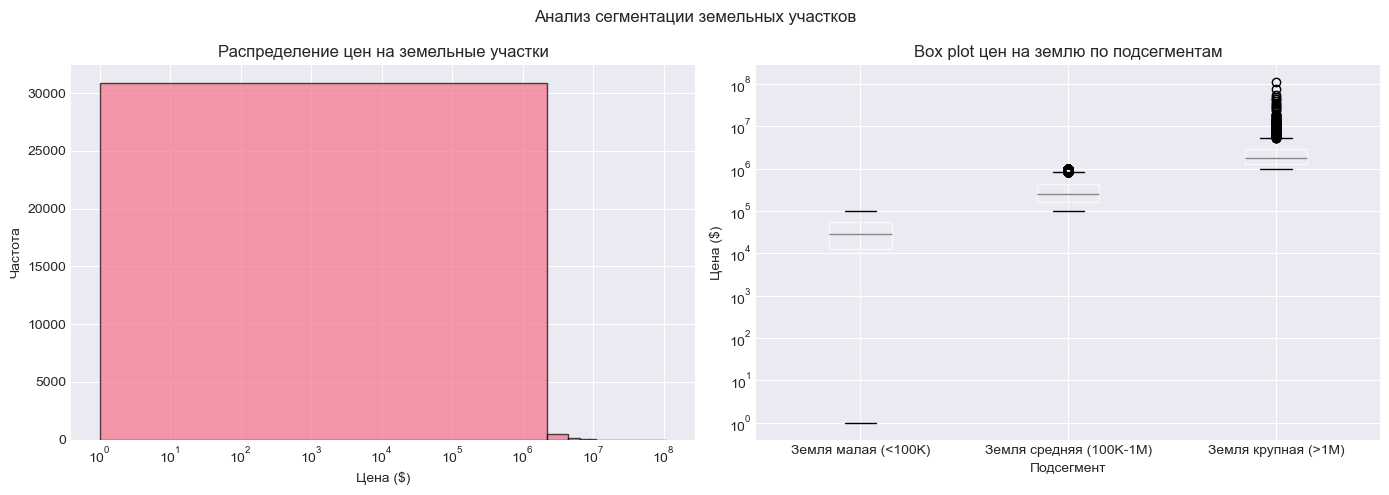

In [22]:
print("=== АНАЛИЗ ЗЕМЕЛЬНЫХ УЧАСТКОВ ПО ЦЕНОВЫМ СЕГМЕНТАМ ===\n")

# Берём только земельные участки
df_land = df_all[df_all['price_segment'] == 'Земельные участки'].copy()

# Создаём подсегменты земли
land_bins = [0, 100000, 1000000, 1e9]
land_labels = ['Земля малая (<100K)', 'Земля средняя (100K-1M)', 'Земля крупная (>1M)']
df_land['land_subsegment'] = pd.cut(df_land['target_clean'], bins=land_bins, labels=land_labels)

print("РАСПРЕДЕЛЕНИЕ ЗЕМЕЛЬНЫХ УЧАСТКОВ ПО ПОДСЕГМЕНТАМ:")
print(df_land['land_subsegment'].value_counts())

print("\nСТАТИСТИКА ПО ПОДСЕГМЕНТАМ ЗЕМЛИ:")
stats = df_land.groupby('land_subsegment').agg({
    'target_clean': ['count', 'min', 'max', 'mean', 'median']
}).round(0)
print(stats)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма цен земли
axes[0].hist(df_land['target_clean'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение цен на земельные участки')
axes[0].set_xlabel('Цена ($)')
axes[0].set_ylabel('Частота')
axes[0].set_xscale('log')

# Box plot по подсегментам
df_land.boxplot(column='target_clean', by='land_subsegment', ax=axes[1])
axes[1].set_title('Box plot цен на землю по подсегментам')
axes[1].set_xlabel('Подсегмент')
axes[1].set_ylabel('Цена ($)')
axes[1].set_yscale('log')

plt.suptitle('Анализ сегментации земельных участков')
plt.tight_layout()
plt.savefig('data_processed/eda_land_segmentation.png', dpi=150)
plt.show()

In [23]:
print("=== МОДЕЛЬ ТОЛЬКО НА ЗДАНИЯХ ===\n")

# Только здания
df_houses = df_model[df_model['is_land'] == 0].copy()
X_houses = df_houses.drop(['target', 'target_clean', 'is_land'], axis=1)
y_houses = df_houses['target_clean']

def train_and_evaluate_simple(X, y, name):
    X = X.copy()
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: MAE=${mae:,.0f}, R²={r2:.4f}")
    return r2

# Единая модель на всех данных (для сравнения)
print("БАЗОВЫЕ МОДЕЛИ:")
r2_all = train_and_evaluate_simple(X_all, y_all, "  Единая модель (все данные)")

# Модель только на зданиях
r2_houses = train_and_evaluate_simple(X_houses, y_houses, "  Только здания")

print("\n" + "="*50)
print("ВЫВОД")
print("="*50)
print(f"Единая модель (все данные): R² = {r2_all:.4f}")
print(f"Модель только на зданиях: R² = {r2_houses:.4f}")
print(f"Изменение: +{r2_houses - r2_all:.4f}")

if r2_houses > r2_all:
    print("✅ Исключение земельных участков улучшило качество")
    print("   Рекомендация: в финальной модели использовать только здания")
else:
    print("⚠️ Исключение земли не дало улучшения")

=== МОДЕЛЬ ТОЛЬКО НА ЗДАНИЯХ ===

БАЗОВЫЕ МОДЕЛИ:
  Единая модель (все данные): MAE=$247,469, R²=0.5448
  Только здания: MAE=$250,885, R²=0.4704

ВЫВОД
Единая модель (все данные): R² = 0.5448
Модель только на зданиях: R² = 0.4704
Изменение: +-0.0744
⚠️ Исключение земли не дало улучшения


In [24]:
print("=== СТРАТИФИКАЦИЯ ПО ЦЕНЕ (ВСЕ ОБЪЕКТЫ) ===\n")

# Используем все объекты (и землю, и здания)
df_all_objects = df_model.copy()

# Создаём ценовые сегменты для всех объектов
price_bins = [0, 100000, 500000, 2000000, 1e9]
price_labels = ['Дешёвые (<100K)', 'Эконом (100-500K)', 'Стандарт (500K-2M)', 'Дорогие (>2M)']
df_all_objects['price_segment'] = pd.cut(df_all_objects['target_clean'], bins=price_bins, labels=price_labels)

print("РАСПРЕДЕЛЕНИЕ ПО СЕГМЕНТАМ:")
print(df_all_objects['price_segment'].value_counts())
print()

# Функция обучения модели на сегменте
def train_segment(df_segment, segment_name):
    if len(df_segment) < 100:
        print(f"  {segment_name}: недостаточно данных ({len(df_segment)} объектов)")
        return None

    X = df_segment.drop(['target', 'target_clean', 'is_land', 'price_segment'], axis=1)
    y = df_segment['target_clean']

    # Кодирование категориальных
    X = X.copy()
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"  {segment_name}: MAE=${mae:,.0f}, R²={r2:.4f}, n={len(df_segment):,}")
    return r2, len(df_segment)

# Обучаем модели для каждого сегмента
print("ОБУЧЕНИЕ МОДЕЛЕЙ ПО СЕГМЕНТАМ:")
print("-"*50)

segment_results = {}
total_weighted_r2 = 0
total_samples = 0

for segment in price_labels:
    df_segment = df_all_objects[df_all_objects['price_segment'] == segment]
    result = train_segment(df_segment, segment)
    if result is not None:
        r2, n = result
        segment_results[segment] = {'r2': r2, 'n': n}
        total_weighted_r2 += r2 * n
        total_samples += n

# Взвешенный R²
weighted_r2 = total_weighted_r2 / total_samples

print("\n" + "="*50)
print("СРАВНЕНИЕ ПОДХОДОВ")
print("="*50)

# Единая модель (из ячейки 15)
print(f"Единая модель (все данные): R² = 0.5448")

# Стратифицированная по цене
print(f"Стратифицированная по цене: R² = {weighted_r2:.4f}")
print(f"Улучшение: +{weighted_r2 - 0.5448:.4f}")

if weighted_r2 - 0.5448 > 0.03:
    print("✅ Стратификация по цене оправдана (улучшение > 3%)")
    print("\nРекомендация: разделить данные на 4 ценовых сегмента")
    for segment, data in segment_results.items():
        print(f"  - {segment}: {data['n']:,} объектов, R²={data['r2']:.4f}")
else:
    print("⚠️ Стратификация по цене не дала значительного улучшения")

=== СТРАТИФИКАЦИЯ ПО ЦЕНЕ (ВСЕ ОБЪЕКТЫ) ===

РАСПРЕДЕЛЕНИЕ ПО СЕГМЕНТАМ:
price_segment
Эконом (100-500K)     217880
Стандарт (500K-2M)     92907
Дешёвые (<100K)        46617
Дорогие (>2M)          17299
Name: count, dtype: int64

ОБУЧЕНИЕ МОДЕЛЕЙ ПО СЕГМЕНТАМ:
--------------------------------------------------
  Дешёвые (<100K): MAE=$13,714, R²=0.6254, n=46,617
  Эконом (100-500K): MAE=$41,592, R²=0.6892, n=217,880
  Стандарт (500K-2M): MAE=$192,099, R²=0.5104, n=92,907
  Дорогие (>2M): MAE=$2,160,239, R²=0.3696, n=17,299

СРАВНЕНИЕ ПОДХОДОВ
Единая модель (все данные): R² = 0.5448
Стратифицированная по цене: R² = 0.6222
Улучшение: +0.0774
✅ Стратификация по цене оправдана (улучшение > 3%)

Рекомендация: разделить данные на 4 ценовых сегмента
  - Дешёвые (<100K): 46,617 объектов, R²=0.6254
  - Эконом (100-500K): 217,880 объектов, R²=0.6892
  - Стандарт (500K-2M): 92,907 объектов, R²=0.5104
  - Дорогие (>2M): 17,299 объектов, R²=0.3696


Стратификация по цене даёт улучшение R² на 7.7% (с 0.5448 до 0.6222).

Рекомендуется разделить данные на 4 ценовых сегмента и обучить отдельную модель для каждого. Особенно высокое качество достигается для дешёвых и среднеценовых объектов (R² > 0.68).